# Proyek Klasifikasi Gambar: Animal-10
- **Nama:** Subhan Irsyaduddien Alhaq
- **Email:** subhanirsyaduddien@gmail.com
- **ID Dicoding:** [Input Username]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import sys
import json
import random
import shutil
import zipfile
import subprocess
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Helper install (untuk Colab/Notebook lokal)
def pip_install(pkg: str):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import kagglehub
except ImportError:
    pip_install("kagglehub")
    import kagglehub

try:
    import tensorflowjs as tfjs
except ImportError:
    pip_install("tensorflowjs")
    import tensorflowjs as tfjs

# Reproducibility
SEED = 42
keras.utils.set_random_seed(SEED)

# Hyperparameter utama
IMG_SIZE = (224, 224)      # cocok untuk transfer learning (MobileNetV2)
BATCH_SIZE = 32
BASE_EPOCHS = 10           # tahap 1: train head
FINE_TUNE_EPOCHS = 10      # tahap 2: fine-tune sebagian base model

TEST_SIZE = 0.20
VAL_SIZE = 0.20

SUBMISSION_DIR = Path("submission")
SAVED_MODEL_DIR = SUBMISSION_DIR / "saved_model"
TFLITE_DIR = SUBMISSION_DIR / "tflite"
TFJS_DIR = SUBMISSION_DIR / "tfjs_model"

for d in [SUBMISSION_DIR, SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

AUTOTUNE = tf.data.AUTOTUNE


TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

Using Colab cache for faster access to the 'animal10' dataset.
Path to dataset files: /kaggle/input/animal10
DATA_ROOT: /kaggle/input/animal10/Animals-10
Jumlah kelas: 10
Kelas: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']

Jumlah gambar per kelas:
- butterfly           : 2112
- cat                 : 1668
- chicken             : 3098
- cow                 : 1866
- dog                 : 4863
- elephant            : 1446
- horse               : 2623
- sheep               : 1820
- spider              : 4821
- squirrel            : 1862
TOTAL: 26179


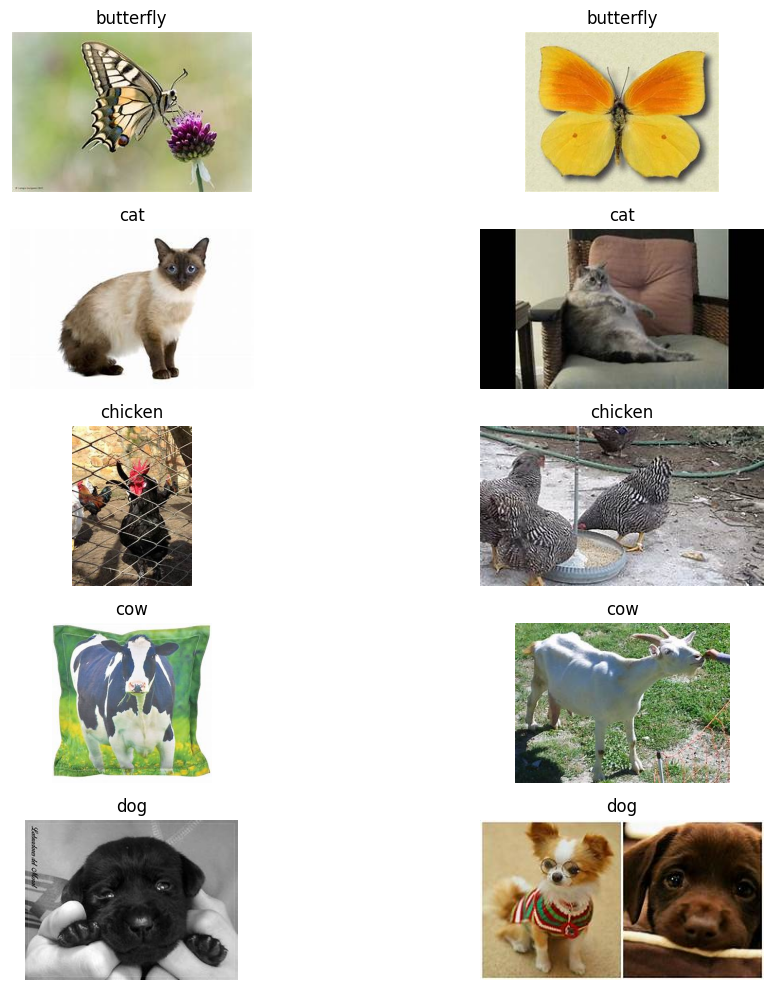

butterfly: 2112
cat: 1668
chicken: 3098
cow: 1866
dog: 4863
elephant: 1446
horse: 2623
sheep: 1820
spider: 4821
squirrel: 1862

Contoh beberapa resolusi unik (sebagian):
- (640, 320)
- (300, 270)
- (300, 108)
- (300, 126)
- (238, 300)
- (300, 144)
- (286, 218)
- (300, 229)
- (640, 477)
- (300, 238)
- (200, 300)
- (222, 300)
- (211, 300)
- (300, 247)
- (5184, 3456)
---------------
Total dicek (sample): 2000


In [2]:
dataset_path = kagglehub.dataset_download("viratkothari/animal10")
dataset_path = Path(dataset_path)
print("Path to dataset files:", dataset_path)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def looks_like_class_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    subdirs = [x for x in p.iterdir() if x.is_dir()]
    if len(subdirs) < 2:
        return False
    img_count = 0
    for sd in subdirs[:5]:
        for f in sd.iterdir():
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS:
                img_count += 1
                break
    return img_count >= 2

def find_image_root(root: Path) -> Path:
    if looks_like_class_dir(root):
        return root
    candidates = []
    for p in root.rglob("*"):
        if p.is_dir() and looks_like_class_dir(p):
            candidates.append(p)
    if not candidates:
        raise FileNotFoundError("Tidak menemukan folder dataset berbentuk: root/kelas_1/*.jpg, root/kelas_2/*.jpg, ...")
    candidates.sort(key=lambda x: len([d for d in x.iterdir() if d.is_dir()]), reverse=True)
    return candidates[0]

DATA_ROOT = find_image_root(dataset_path)
print("DATA_ROOT:", DATA_ROOT)

# daftar kelas
class_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()], key=lambda x: x.name.lower())
class_names = [d.name for d in class_dirs]
num_classes = len(class_names)

print("Jumlah kelas:", num_classes)
print("Kelas:", class_names)

counts = {}
total_images = 0
for cd in class_dirs:
    n = sum(1 for f in cd.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS)
    counts[cd.name] = n
    total_images += n

print("\nJumlah gambar per kelas:")
for k, v in counts.items():
    print(f"- {k:20s}: {v}")
print("TOTAL:", total_images)

def show_samples(data_root: Path, class_names: list[str], n_per_class: int = 2):
    plt.figure(figsize=(12, 10))
    plot_idx = 1
    for cls in class_names[:5]:
        cls_dir = data_root / cls
        imgs = [p for p in cls_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
        if not imgs:
            continue
        random.shuffle(imgs)
        for i in range(min(n_per_class, len(imgs))):
            img = Image.open(imgs[i]).convert("RGB")
            plt.subplot(5, n_per_class, plot_idx)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
            plot_idx += 1
    plt.tight_layout()
    plt.show()

show_samples(DATA_ROOT, class_names, n_per_class=2)

def print_images_resolution(directory: Path, max_per_class: int = 200):
    unique_sizes = set()
    total_images_seen = 0
    for subdir in sorted([d for d in directory.iterdir() if d.is_dir()]):
        image_files = [f for f in subdir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS]
        print(f"{subdir.name}: {len(image_files)}")
        take = image_files[:max_per_class]
        for img_path in take:
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
                    total_images_seen += 1
            except Exception:
                pass

    print("\nContoh beberapa resolusi unik (sebagian):")
    for i, size in enumerate(list(unique_sizes)[:15]):
        print(f"- {size}")
    print("---------------")
    print(f"Total dicek (sample): {total_images_seen}")

print_images_resolution(DATA_ROOT)


### Data Preprocessing

#### Split Dataset

In [3]:
all_paths = []
all_labels = []

label_to_index = {name: idx for idx, name in enumerate(class_names)}

for cls in class_names:
    cls_dir = DATA_ROOT / cls
    files = [p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    for f in files:
        all_paths.append(str(f))
        all_labels.append(label_to_index[cls])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

print("Total data:", len(all_paths))

X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y_trainval
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))


def decode_and_resize(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.int32)
    return img, label


def make_dataset(paths, labels, training: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

for images, labels in train_ds.take(1):
    print("Batch images:", images.shape, images.dtype)
    print("Batch labels:", labels.shape, labels.dtype)


Total data: 26179
Train: 16754 Val: 4189 Test: 5236
Batch images: (32, 224, 224, 3) <dtype: 'float32'>
Batch labels: (32,) <dtype: 'int32'>


## Modelling

In [4]:
# Data augmentation (aktif hanya saat training)
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        # 40-60 derajat ~ 0.11 - 0.17 dari 2*pi
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.25),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.10, 0.10),
    ],
    name="data_augmentation"
)

# Transfer Learning: MobileNetV2 (ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

# Model tetap Sequential + ada Conv2D + Pooling (sesuai kriteria)
model = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        data_augmentation,
        # Preprocess MobileNetV2: skala ke [-1, 1]
        layers.Rescaling(1.0 / 127.5, offset=-1.0),

        base_model,

        # Tambahan Conv2D + Pooling untuk memenuhi syarat layer eksplisit
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.30),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="mobilenetv2_animal10"
)

model.summary()

# Class weight (dataset bisa imbalance) -> bantu akurasi per kelas
class_counts = np.bincount(y_train, minlength=num_classes)
class_weight = {i: float(class_counts.sum() / (num_classes * c)) for i, c in enumerate(class_counts) if c > 0}
print("Class counts:", class_counts)
print("Class weight (sample):", dict(list(class_weight.items())[:3]))

# Tahap 1: train head
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASE_EPOCHS,
    callbacks=callbacks_stage1,
    class_weight=class_weight,
)

# Tahap 2: fine-tune sebagian base model (biasanya menaikkan akurasi)
base_model.trainable = True

# Freeze sebagian besar layer, fine-tune bagian akhir
fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNorm umumnya tetap freeze saat fine-tuning untuk stabil
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_stage2,
    class_weight=class_weight,
)

# Load best checkpoint untuk evaluasi & export
if Path("best_model.keras").exists():
    model = keras.models.load_model("best_model.keras")
    print("Loaded best_model.keras")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_animal10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,275,722 (20.13 MB)

 Trainable params: 3,017,738 (11.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Class counts: [1352 1067 1982 1194 3112  926 1678 1165 3086 1192]
Class weight (sample): {0: 1.2392011834319527, 1: 1.5701968134957827, 2: 0.8453077699293643}
Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7060 - loss: 1.3067
Epoch 1: val_accuracy improved from -inf to 0.93387, saving model to best_model.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.7062 - loss: 1.3057 - val_accuracy: 0.9339 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 2/10
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8479 - loss: 0.5121
Epoch 2: val_accuracy improved from 0.93387 to 0.95273, saving model to best_model.keras
524/524 ━━━━━━━━━━━━━━━━━━━━ 47s 82ms/step - accuracy: 0.8480 - loss: 0.5120 - val_accuracy: 0.9527 - val_loss: 0.1812 - learning_rate: 0.0010
Epoch 3/10
523/524 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8765 - loss: 0.4295
Epoch 3: val_accuracy did not improve from 0.95273
524/524 ━━━━━━━━━━━━━━━━━━━━ 43s 81ms/step - accuracy: 0.8765 - los

## Evaluasi dan Visualisasi

Train Acc: 0.9772 | Train Loss: 0.0786
Val   Acc: 0.9666 | Val   Loss: 0.1199
Test  Acc: 0.9635 | Test  Loss: 0.1337


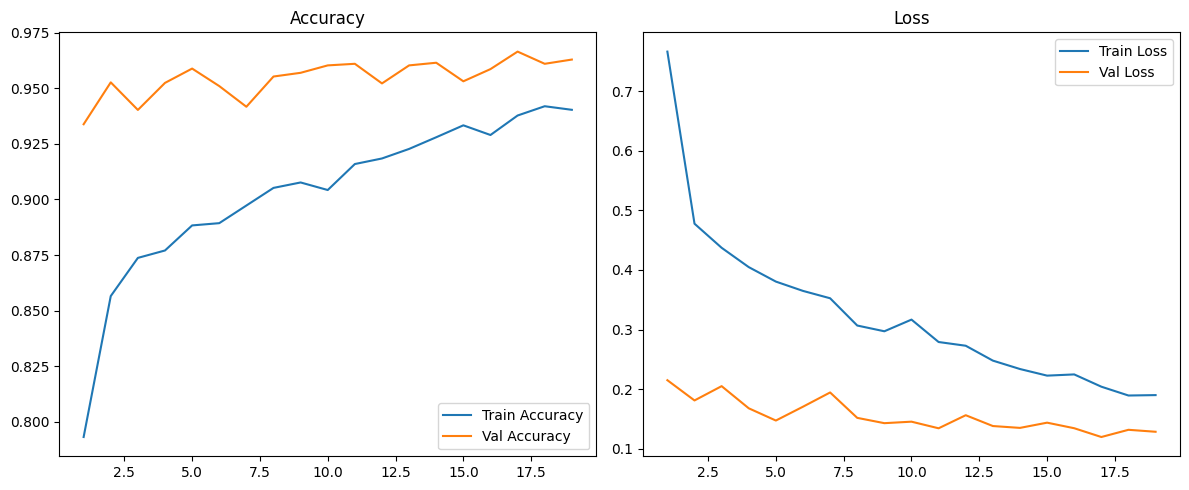

Confusion Matrix shape: (10, 10)

Classification Report:
              precision    recall  f1-score   support

   butterfly       0.97      0.99      0.98       422
         cat       0.94      0.97      0.95       334
     chicken       0.98      0.98      0.98       620
         cow       0.92      0.92      0.92       373
         dog       0.97      0.96      0.96       973
    elephant       0.95      0.97      0.96       289
       horse       0.94      0.96      0.95       525
       sheep       0.93      0.94      0.93       364
      spider       1.00      0.98      0.99       964
    squirrel       0.99      0.95      0.97       372

    accuracy                           0.96      5236
   macro avg       0.96      0.96      0.96      5236
weighted avg       0.96      0.96      0.96      5236



In [5]:
# Evaluasi (gunakan model terbaik)
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Val   Acc: {val_acc:.4f} | Val   Loss: {val_loss:.4f}")
print(f"Test  Acc: {test_acc:.4f} | Test  Loss: {test_loss:.4f}")

# Gabungkan history (stage1 + stage2) untuk plot
history_all = {}
for k, v in history_stage1.history.items():
    history_all[k] = list(v)
for k, v in history_stage2.history.items():
    history_all.setdefault(k, []).extend(list(v))

acc = history_all.get("accuracy", [])
val_acc_hist = history_all.get("val_accuracy", [])
loss = history_all.get("loss", [])
val_loss_hist = history_all.get("val_loss", [])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc_hist, label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss_hist, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.tight_layout()
plt.show()

# Confusion matrix + classification report
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix shape:", cm.shape)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


## Konversi Model

In [10]:
# Konversi Model
# Catatan reviewer: saat menyimpan SavedModel, TF-Lite, TFJS tidak perlu mendefinisikan ulang / melatih ulang model.
# Gunakan model terbaik yang sudah dilatih & dievaluasi di atas.

import sys
import shutil
import subprocess
from pathlib import Path

import tensorflow as tf

SUBMISSION_DIR = Path("submission")
SAVED_MODEL_DIR = SUBMISSION_DIR / "saved_model"
TFLITE_DIR = SUBMISSION_DIR / "tflite"
TFJS_DIR = SUBMISSION_DIR / "tfjs_model"

for d in [SUBMISSION_DIR, SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Pastikan model sudah built (penting untuk beberapa environment)
_ = model(tf.zeros([1, IMG_SIZE[0], IMG_SIZE[1], 3], dtype=tf.float32), training=False)

# 1) SavedModel
# NOTE:
# - Pada beberapa kombinasi Python 3.12 + TF/Keras tertentu,
#   tf.saved_model.save(..., signatures={...}) dapat memicu error TypeError _DictWrapper.
# - Solusi paling aman: export SavedModel tanpa custom signatures.

if SAVED_MODEL_DIR.exists():
    shutil.rmtree(SAVED_MODEL_DIR)
SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

saved_ok = False
# Keras 3 menyediakan `model.export()` untuk SavedModel
if hasattr(model, "export"):
    try:
        model.export(str(SAVED_MODEL_DIR))
        saved_ok = True
    except Exception as e:
        print("model.export() gagal, fallback ke tf.saved_model.save. Error:", e)

if not saved_ok:
    # Fallback universal
    tf.saved_model.save(model, str(SAVED_MODEL_DIR))

print("SavedModel saved to:", SAVED_MODEL_DIR)
print("saved_model.pb exists:", (SAVED_MODEL_DIR / "saved_model.pb").exists())

# 2) TFLite
if TFLITE_DIR.exists():
    shutil.rmtree(TFLITE_DIR)
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

# Konversi langsung dari Keras model (lebih tahan terhadap isu signature)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# fallback aman jika ada op yang belum didukung sepenuhnya
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]

tflite_model = converter.convert()

tflite_path = TFLITE_DIR / "model.tflite"
tflite_path.write_bytes(tflite_model)
print("TFLite saved to:", tflite_path)

# label.txt (WAJIB)
label_path = TFLITE_DIR / "label.txt"
with open(label_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")
print("Labels saved to:", label_path)
# 3) TFJS (Perbaikan: Menggunakan format .h5 agar kompatibel)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflowjs"])

if TFJS_DIR.exists():
    shutil.rmtree(TFJS_DIR)
TFJS_DIR.mkdir(parents=True, exist_ok=True)

# Ganti ekstensi dari .keras menjadi .h5
# Format .h5 lebih dikenali oleh tensorflowjs converter
h5_path = SUBMISSION_DIR / "model.h5"

if h5_path.exists():
    h5_path.unlink()

# Simpan model ke format .h5
# Pastikan menggunakan variabel 'model' atau 'export_model' yang benar.
# Jika 'export_model' tidak didefinisikan sebelumnya, ganti menjadi 'model'.
try:
    # Coba gunakan export_model jika ada (seperti di kode asli Anda)
    export_model.save(h5_path, save_format='h5', include_optimizer=False)
except NameError:
    # Jika error, gunakan variabel 'model' utama
    print("Variabel export_model tidak ditemukan, menggunakan 'model'...")
    model.save(h5_path, save_format='h5', include_optimizer=False)

cmd_layers = [
    sys.executable, "-m", "tensorflowjs.converters.converter",
    "--input_format", "keras",
    "--output_format", "tfjs_layers_model",
    str(h5_path),  # Gunakan path file .h5
    str(TFJS_DIR),
]

print("Running:", " ".join(cmd_layers))

# Tambahkan try-except untuk melihat error detail jika masih gagal
try:
    subprocess.check_call(cmd_layers)
    print("TFJS output files:")
    for p in sorted(TFJS_DIR.iterdir()):
        print("-", p.name)
except subprocess.CalledProcessError as e:
    print(f"Error saat konversi TFJS: {e}")
    # Tips debug: Jalankan perintah ini manual di terminal untuk melihat pesan error lengkapnya


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138179031819920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138179031820496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138179031820304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817672208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817673168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817670672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817673360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817670864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817672016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177817671632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138177

Running: /usr/bin/python3 -m tensorflowjs.converters.converter --input_format keras --output_format tfjs_layers_model submission/model.h5 submission/tfjs_model
TFJS output files:
- group1-shard1of6.bin
- group1-shard2of6.bin
- group1-shard3of6.bin
- group1-shard4of6.bin
- group1-shard5of6.bin
- group1-shard6of6.bin
- model.json


## Inference (Optional)

Input details: [{'name': 'serving_default_input_layer_1:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 183, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Sample path: /kaggle/input/animal10/Animals-10/squirrel/squirrel (72).jpeg
True label: squirrel
Predicted: squirrel (conf=0.9982)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


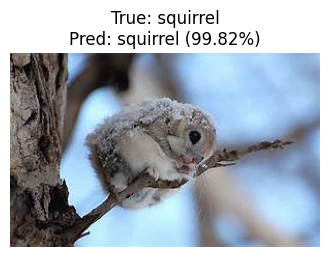

In [8]:
# Inference (Optional) - TFLite

interpreter = tf.lite.Interpreter(model_path=str(TFLITE_DIR / "model.tflite"))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

sample_path = X_test[0]
sample_label = y_test[0]
print("Sample path:", sample_path)
print("True label:", class_names[int(sample_label)])

img = Image.open(sample_path).convert("RGB")
img_resized = img.resize(IMG_SIZE)
# input float32 (0..255) -> model punya Rescaling internal
x = np.array(img_resized, dtype=np.float32)
x = np.expand_dims(x, axis=0)

interpreter.set_tensor(input_details[0]["index"], x)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]["index"])

pred_idx = int(np.argmax(pred, axis=1)[0])
pred_name = class_names[pred_idx]
pred_conf = float(np.max(pred))

print(f"Predicted: {pred_name} (conf={pred_conf:.4f})")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"True: {class_names[int(sample_label)]}\nPred: {pred_name} ({pred_conf:.2%})")
plt.axis("off")
plt.show()
